### PREPARATION

In [21]:
import yaml
import logging
import pypsa
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import numpy as np
from shapely.geometry import LineString
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import sys
import matplotlib.lines as mlines
from matplotlib.patches import Wedge
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates


In [22]:
logging.getLogger("pypsa.io").setLevel(logging.ERROR)
warnings.simplefilter(action='ignore', category=ResourceWarning)

country_name = "Romania" # Bulgaria, Romania
run_name = "1h-sec-2"

# Load the UHS and woUHS networks
country = pypsa.Network(f"/mnt/e/HySEE/{country_name}/pypsa-earth/results/postnetworks/elec_s_10_ec_lcopt_Co2L0.45-1h_1h_2030_0.07_AB_0export.nc")
# Load geographic data for onshore regions and ports
regions_onshore = gpd.read_file(f"/mnt/e/HySEE/{country_name}/pypsa-earth/resources/{run_name}/shapes/country_shapes.geojson")
ports = pd.read_csv(f"/mnt/e/HySEE/{country_name}/pypsa-earth/resources/ports.csv")

# Create a GeoDataFrame for ports with point geometries
ports = gpd.GeoDataFrame(
    ports,
    geometry=gpd.points_from_xy(ports["x"], ports["y"]),
    crs="EPSG:4326"  # Coordinates are in WGS84
)

# Load GADM shapes and configuration file
gadm_shapes = gpd.read_file(f"/mnt/e/HySEE/{country_name}/pypsa-earth/resources/{run_name}/shapes/gadm_shapes.geojson")
config = yaml.safe_load(open(f"/mnt/e/HySEE/HySEE-Preparation/config/{country_name}/config.yaml"))

# Define paths for network and renewable profiles
network_path = f"/mnt/e/HySEE/{country_name}/pypsa-earth/networks/{run_name}/elec.nc"
solar_path = f"/mnt/e/HySEE/{country_name}/pypsa-earth/resources/{run_name}/renewable_profiles/profile_solar.nc"
onwind_path = f"/mnt/e/HySEE/{country_name}/pypsa-earth/resources/{run_name}/renewable_profiles/profile_onwind.nc"

# Get the bounding box for the onshore regions
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]

# Define colors for scenarios
tech_colors = config["plotting"]["tech_colors"]

# Normalize the carrier column/index to lowercase for easier matching
def get_color(carrier):
    # First, check for an exact match
    if carrier in tech_colors:
        return tech_colors[carrier]
    # Try matching with lowercase
    if carrier.lower() in tech_colors:
        return tech_colors[carrier.lower()]
    # Default color if no match is found
    return "lightgrey"

# Map colors to carriers in the UHS network
country.carriers["color"] = country.carriers.index.map(get_color)

warnings.simplefilter(action='default', category=ResourceWarning)

In [23]:
plt.rcParams.update({
    # Font sizes
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    # Clean journal style
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Figure defaults
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Improve spacing
    "axes.titlepad": 10,
    "axes.labelpad": 6,
})

#### Show PV and Wind Potential

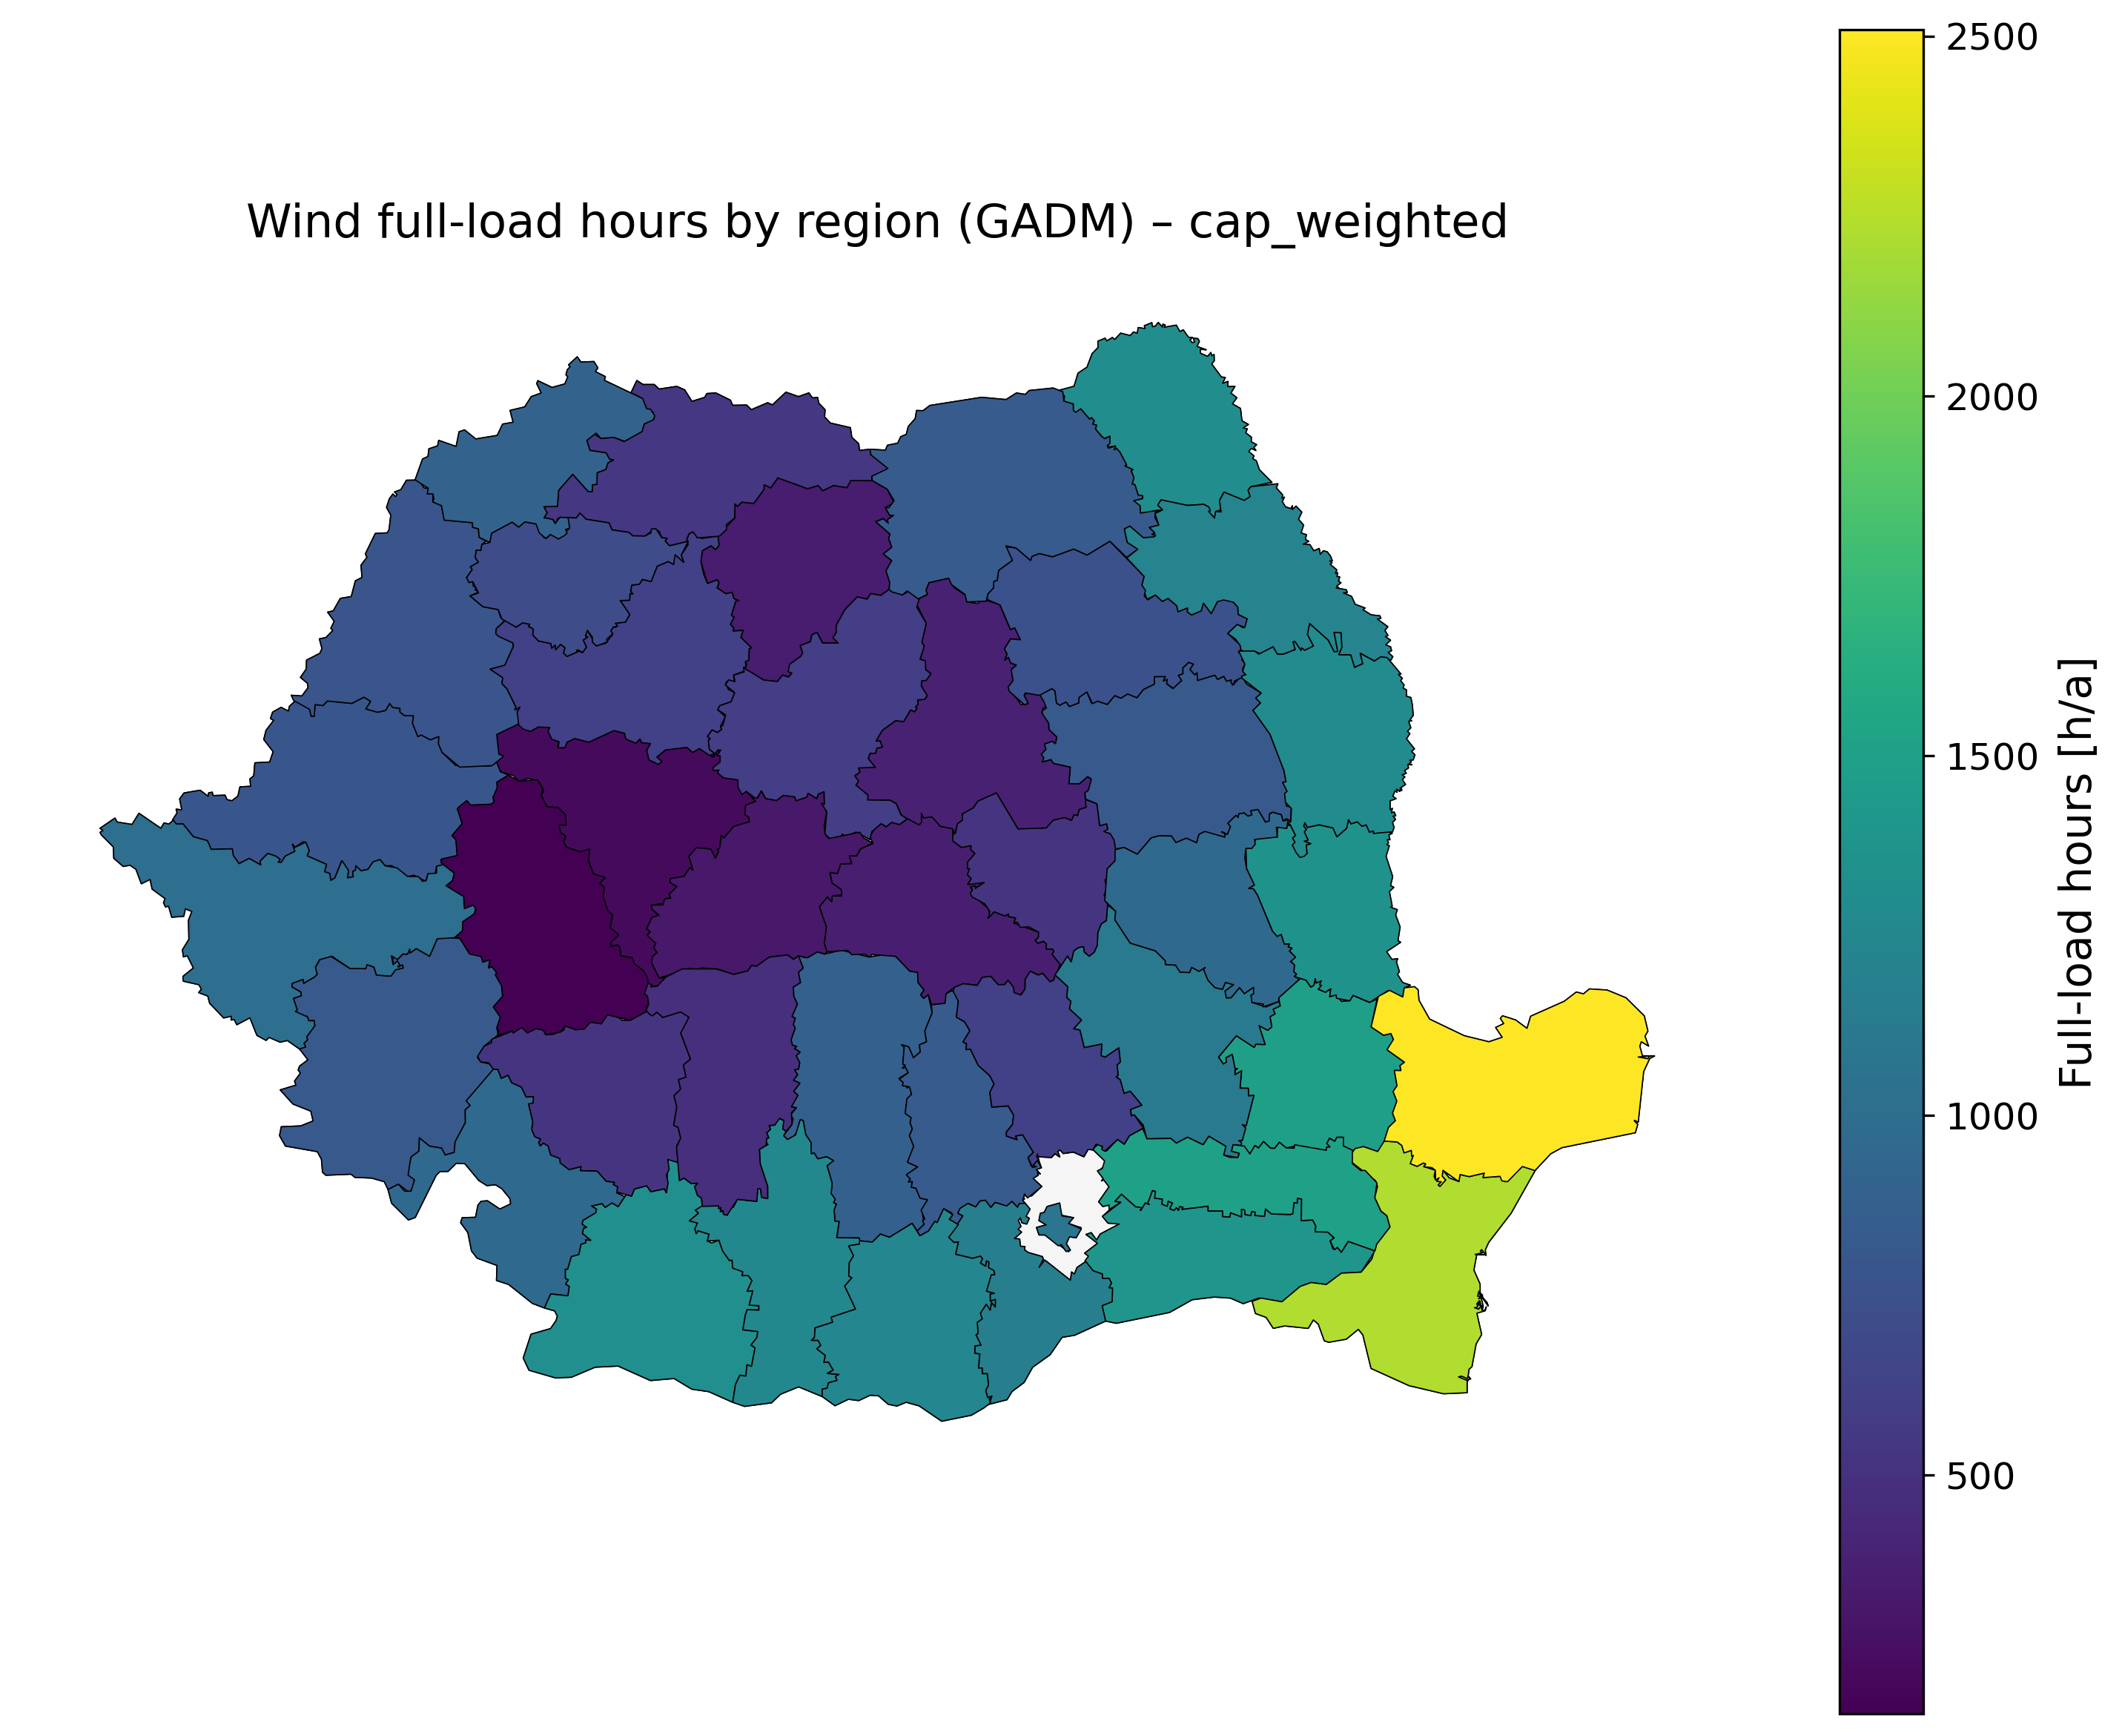

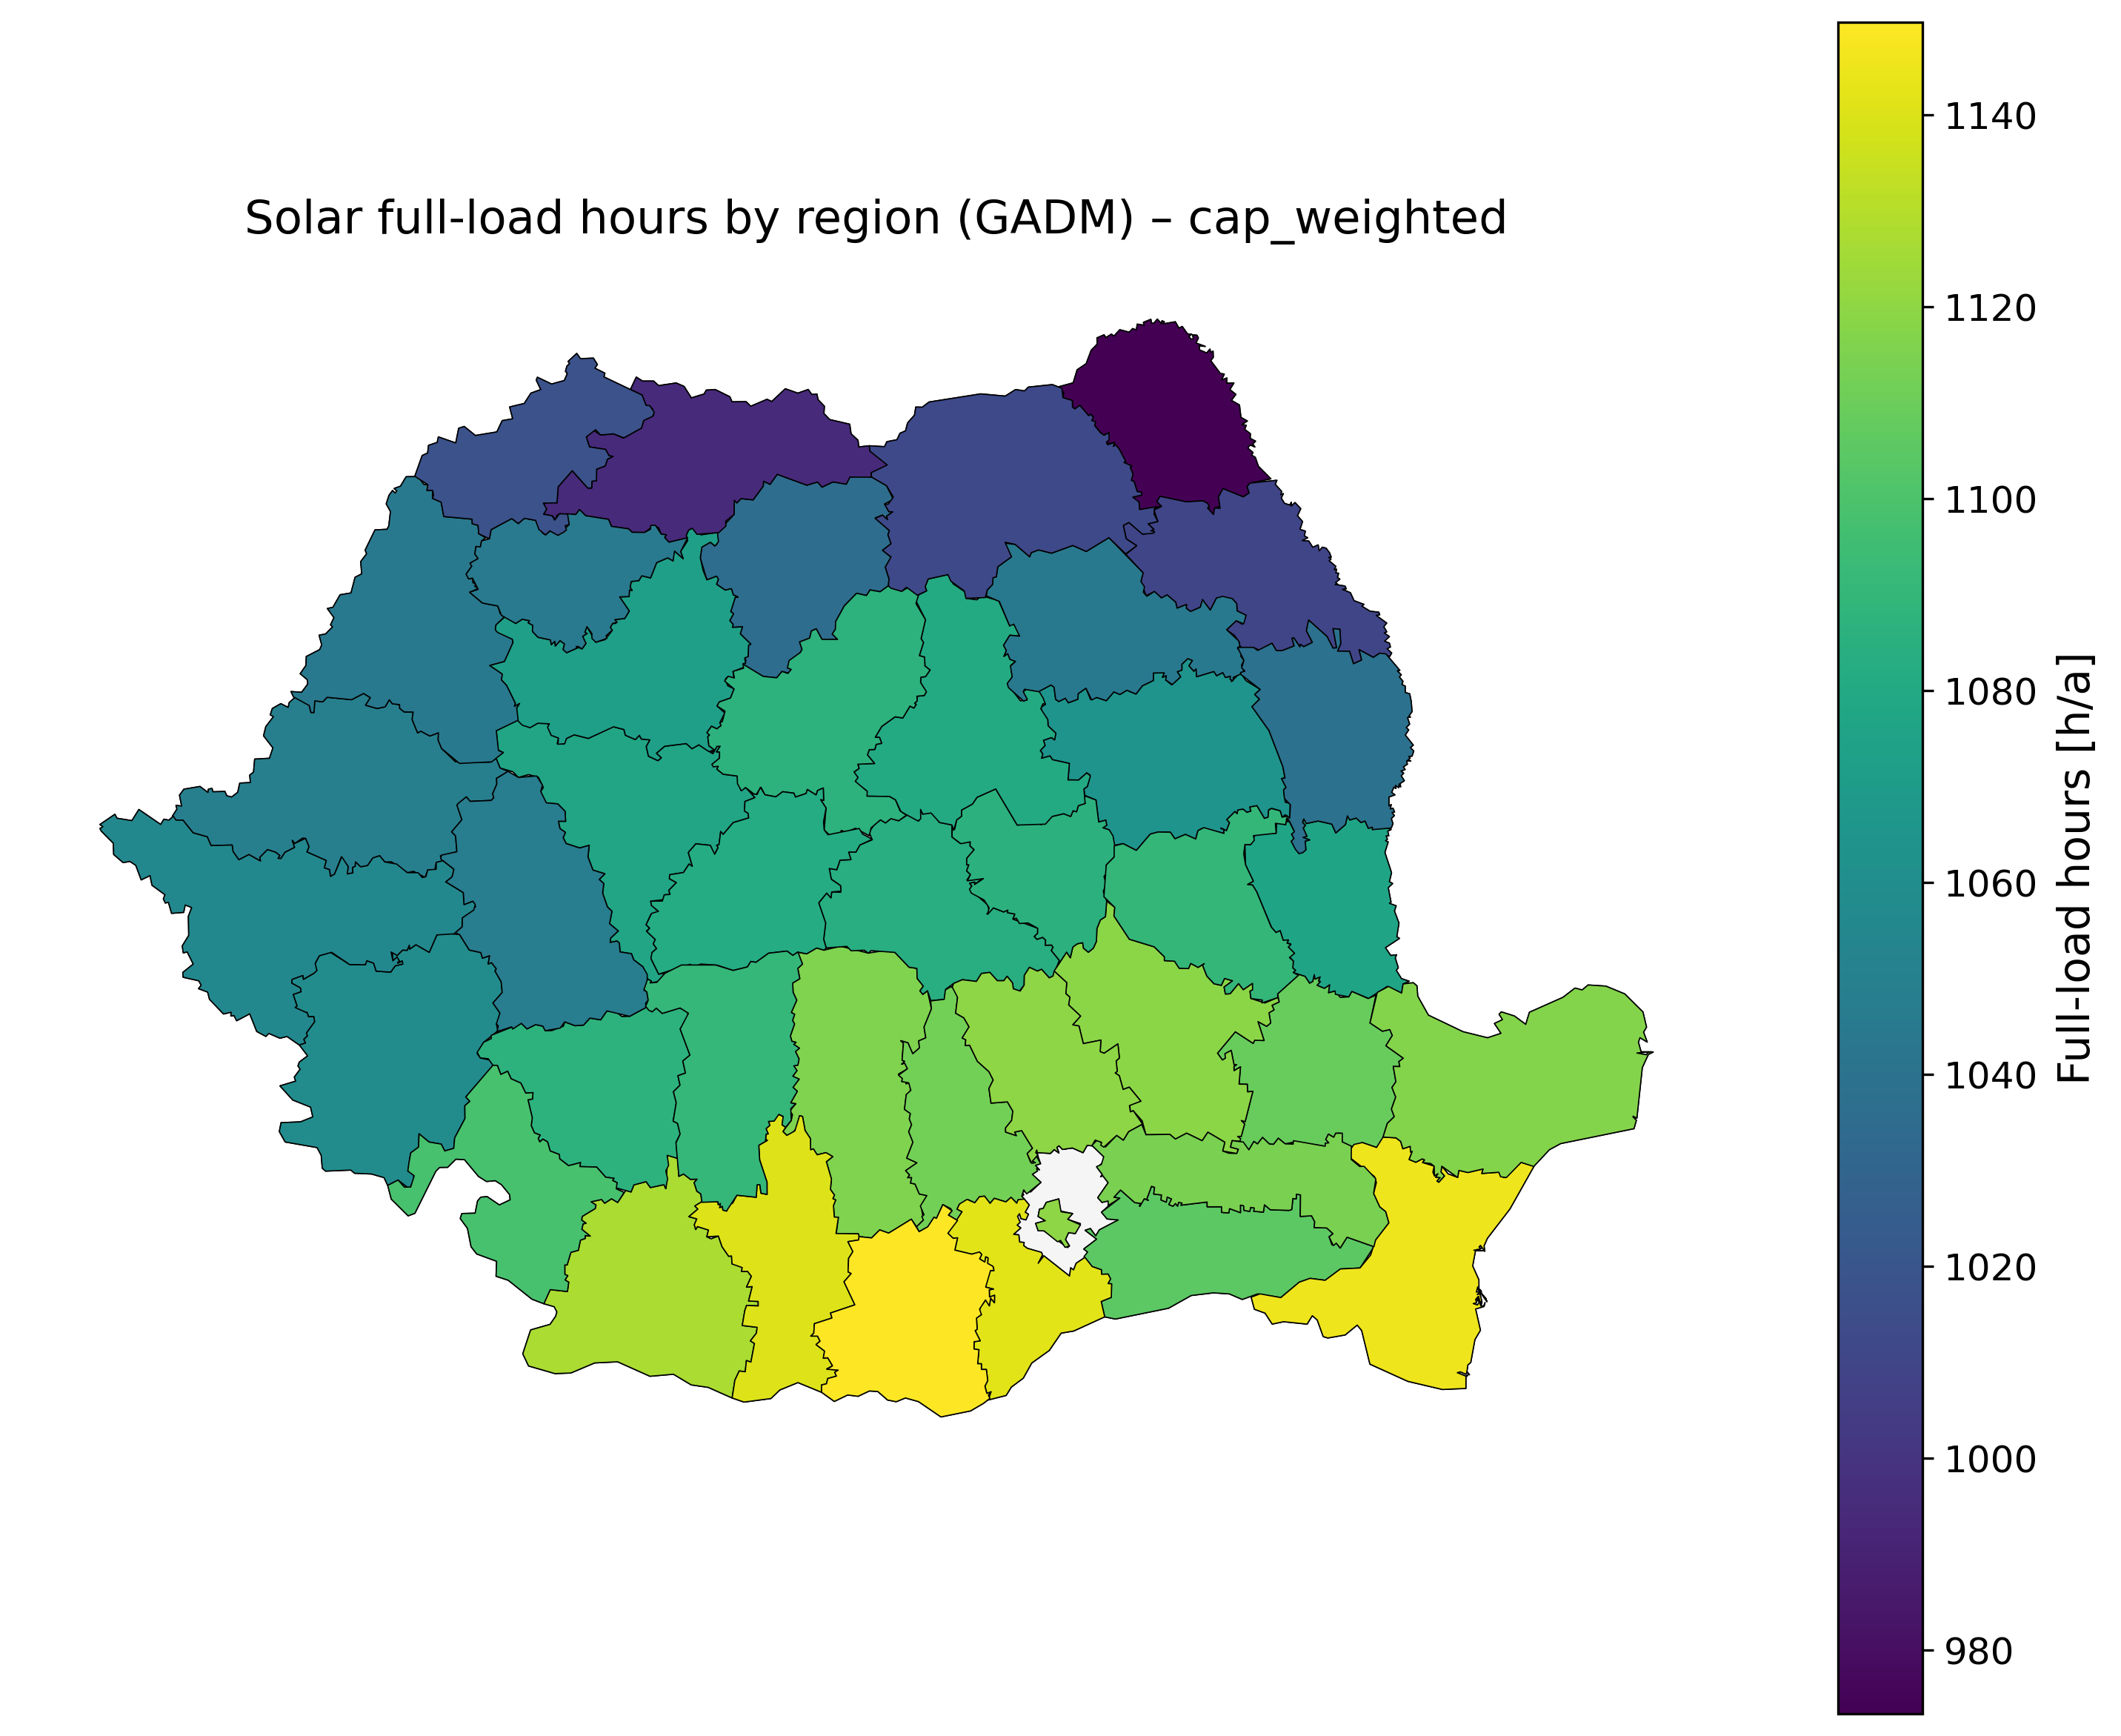

In [24]:
# ============================================================
# SETTINGS
# ============================================================

net = country

# Adjust carriers to your network naming
WIND_CARRIERS = ["onwind", "offwind-ac", "offwind-dc", "wind"]
SOLAR_CARRIERS = ["solar", "solar rooftop", "pv"]

# Choose how to aggregate multiple buses per polygon:
#   "mean"          -> simple average of bus FLH in the polygon
#   "cap_weighted"  -> capacity-weighted average (recommended)
AGG_METHOD = "cap_weighted"

# Optional: choose which polygon id/name column to show in titles / debugging
# If you don't know, set to None; code will still work.
REGION_NAME_COL = None  # e.g. "NAME_1" or "name" depending on your gadm_shapes

FIGSIZE = (10, 8)

# You must have:
#   gadm_shapes : GeoDataFrame with polygons, CRS EPSG:4326 (or will be converted)
# already loaded in your notebook.
# ============================================================


# ============================================================
# HELPERS
# ============================================================

def _snapshot_weights(net):
    if hasattr(net, "snapshot_weightings") and net.snapshot_weightings is not None:
        try:
            if "generators" in net.snapshot_weightings:
                return net.snapshot_weightings["generators"]
        except Exception:
            pass
    return pd.Series(1.0, index=net.snapshots)


def _bus_points_gdf(net):
    """Bus points as GeoDataFrame (EPSG:4326)."""
    buses = net.buses.copy()
    buses = buses.dropna(subset=["x", "y"])
    gdf = gpd.GeoDataFrame(
        buses,
        geometry=gpd.points_from_xy(buses["x"], buses["y"]),
        crs="EPSG:4326"
    )
    return gdf


def flh_by_bus(net, carriers):
    """
    Full-load hours per bus for given generator carriers:
      FLH_bus = sum(E_gen_bus) / sum(P_nom_bus)
    Returns:
      flh (Series indexed by bus)
      p_bus (Series indexed by bus) installed capacity [MW] used for weighting
    """
    w = _snapshot_weights(net)

    gens = net.generators.copy()
    gens = gens[gens.carrier.astype(str).isin(carriers)].copy()
    if gens.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    pnom_col = "p_nom_opt" if "p_nom_opt" in gens.columns else "p_nom"
    p_nom = gens[pnom_col].fillna(0.0)

    # Production time series [MW]
    p = net.generators_t.p[gens.index]
    e_mwh = (p.mul(w, axis=0)).sum(axis=0)  # MWh/a per generator

    # Aggregate to bus
    e_bus = e_mwh.groupby(gens["bus"]).sum()
    p_bus = p_nom.groupby(gens["bus"]).sum()

    flh = (e_bus / p_bus.replace(0.0, np.nan)).dropna()
    p_bus = p_bus.reindex(flh.index).fillna(0.0)

    return flh, p_bus


def aggregate_bus_metric_to_polygons(gadm_shapes, bus_gdf, metric_bus, weight_bus=None, agg_method="cap_weighted"):
    """
    Spatial join bus points -> polygons, then aggregate bus metric to polygon level.

    Returns a copy of gadm_shapes with new column 'value' (polygon-level metric).
    """
    # Ensure CRS match
    poly = gadm_shapes.copy()
    if poly.crs is None:
        poly = poly.set_crs("EPSG:4326")
    if bus_gdf.crs is None:
        bus_gdf = bus_gdf.set_crs("EPSG:4326")
    if poly.crs != bus_gdf.crs:
        bus_gdf = bus_gdf.to_crs(poly.crs)

    # Prepare bus dataframe for join
    b = bus_gdf.loc[metric_bus.index].copy()
    b["metric"] = metric_bus
    if weight_bus is not None:
        b["weight"] = weight_bus.reindex(metric_bus.index).fillna(0.0)
    else:
        b["weight"] = 1.0

    # Spatial join: assign each bus point to a polygon
    joined = gpd.sjoin(b[["metric", "weight", "geometry"]], poly, how="inner", predicate="within")
    # joined has index_right = polygon index
    if joined.empty:
        out = poly.copy()
        out["value"] = np.nan
        return out

    if agg_method == "mean":
        poly_val = joined.groupby("index_right")["metric"].mean()

    elif agg_method == "cap_weighted":
        # weighted mean: sum(metric*weight) / sum(weight)
        num = (joined["metric"] * joined["weight"]).groupby(joined["index_right"]).sum()
        den = joined["weight"].groupby(joined["index_right"]).sum().replace(0.0, np.nan)
        poly_val = (num / den)

    else:
        raise ValueError("agg_method must be 'mean' or 'cap_weighted'")

    out = poly.copy()
    out["value"] = poly_val.reindex(out.index)
    return out


def plot_polygon_map(gdf_polys, title, cmap="viridis"):
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Base polygons in light gray if NaN
    gdf_polys.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=0.4)

    # Colored overlay where value exists
    gdf_polys.dropna(subset=["value"]).plot(
        ax=ax,
        column="value",
        cmap=cmap,
        legend=True,
        legend_kwds={"label": "Full-load hours [h/a]"},
        edgecolor="black",
        linewidth=0.4
    )

    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


# ============================================================
# RUN: WIND + SOLAR maps
# ============================================================

# 1) Prepare bus points once
bus_gdf = _bus_points_gdf(net)

# 2) WIND FLH per bus
wind_present = [c for c in WIND_CARRIERS if c in set(net.generators.carrier.astype(str).unique())]
if len(wind_present) == 0:
    print("No WIND carriers found. Available generator carriers:\n", net.generators.carrier.unique())
else:
    flh_wind, p_wind_bus = flh_by_bus(net, wind_present)
    wind_polys = aggregate_bus_metric_to_polygons(
        gadm_shapes, bus_gdf, flh_wind, weight_bus=p_wind_bus, agg_method=AGG_METHOD
    )
    plot_polygon_map(wind_polys, f"Wind full-load hours by region (GADM) – {AGG_METHOD}")

# 3) SOLAR FLH per bus
solar_present = [c for c in SOLAR_CARRIERS if c in set(net.generators.carrier.astype(str).unique())]
if len(solar_present) == 0:
    print("No SOLAR carriers found. Available generator carriers:\n", net.generators.carrier.unique())
else:
    flh_solar, p_solar_bus = flh_by_bus(net, solar_present)
    solar_polys = aggregate_bus_metric_to_polygons(
        gadm_shapes, bus_gdf, flh_solar, weight_bus=p_solar_bus, agg_method=AGG_METHOD
    )
    plot_polygon_map(solar_polys, f"Solar full-load hours by region (GADM) – {AGG_METHOD}")


In [25]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"/mnt/e/HySEE/{country_name}/pypsa-earth/resources/{run_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

#### Wind potentials

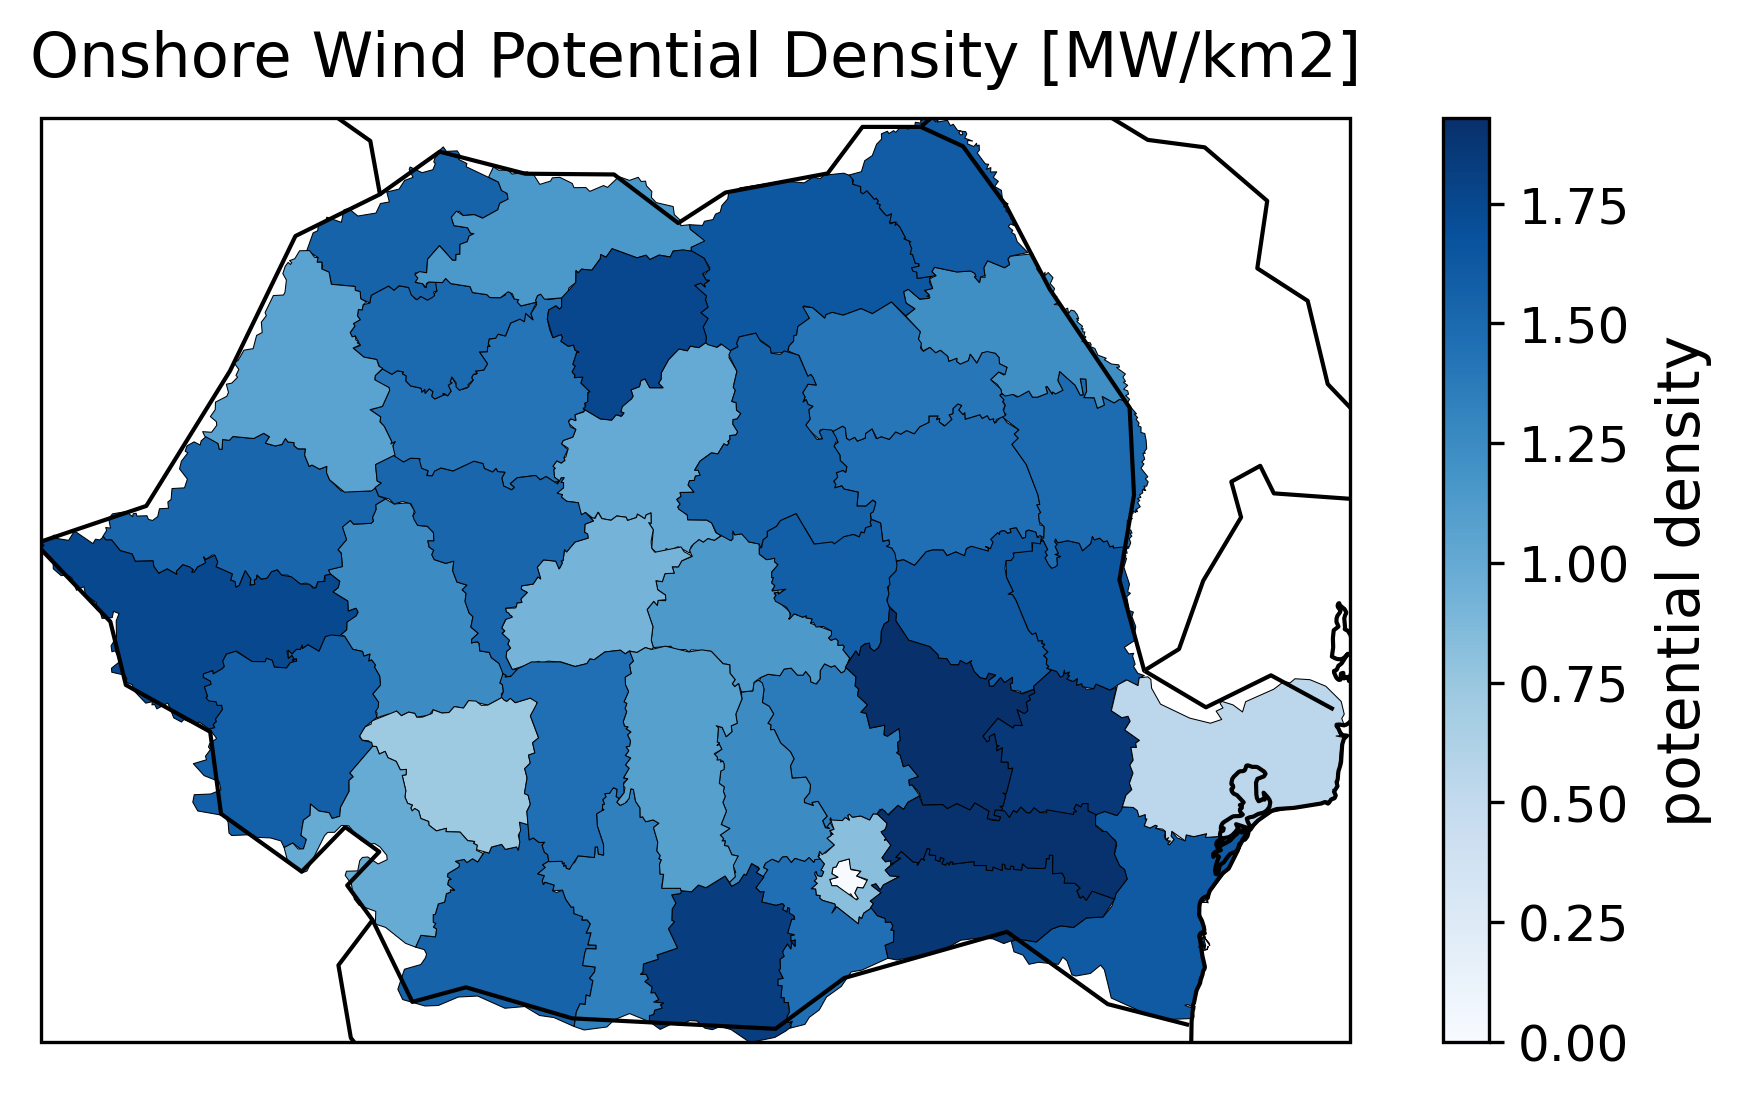

In [26]:
warnings.simplefilter(action='ignore', category=FutureWarning)
logging.getLogger("pypsa.io").setLevel(logging.ERROR)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

#### Solar potentials

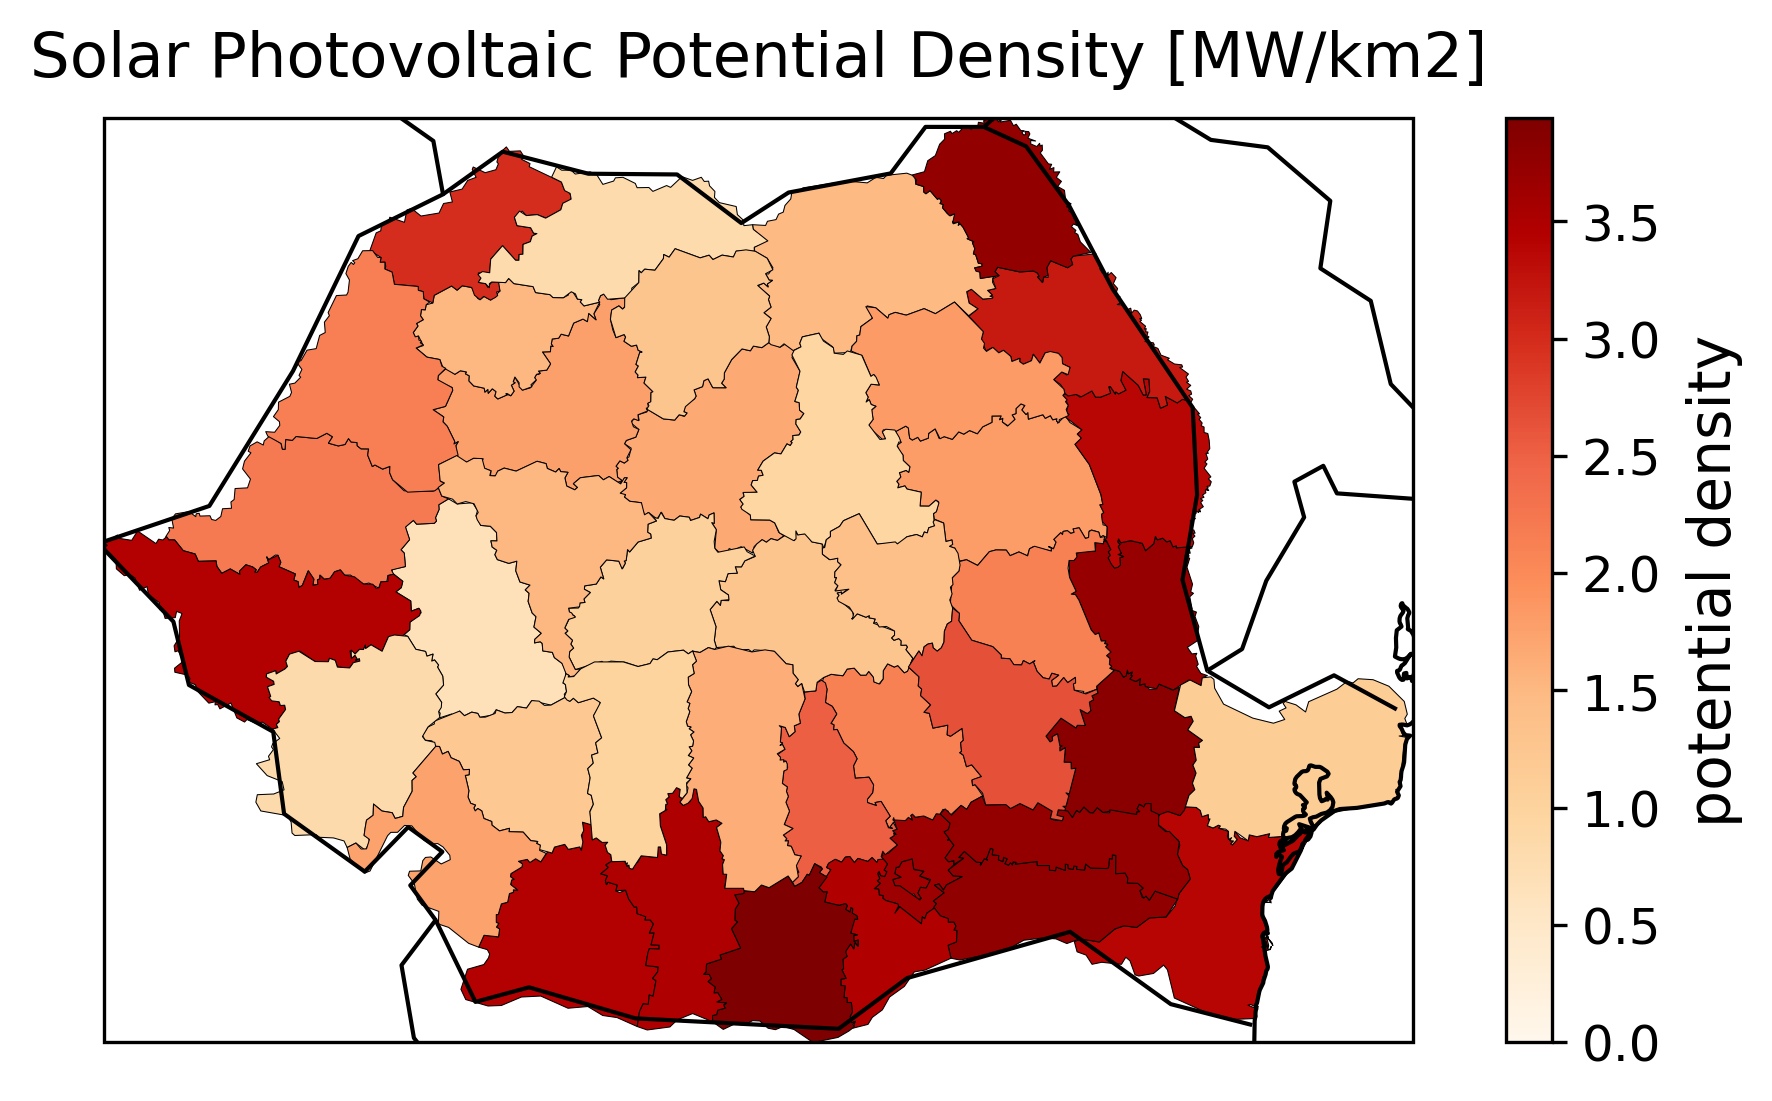

In [27]:
warnings.simplefilter(action='ignore', category=FutureWarning)
logging.getLogger("pypsa.io").setLevel(logging.ERROR)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)